# Dataset Exploration

Profiling `ml_sample_data_snapsoft.csv` to inform preprocessing (task 4) and model training (task 7).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Load and Inspect

In [2]:
df = pd.read_csv("../ml_sample_data_snapsoft.csv")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.dtypes

Shape: 245 rows x 27 columns


car_ID                 int64
CarName                  str
ownername                str
owneremail               str
dealershipaddress        str
saledate                 str
iban                     str
fueltype                 str
aspiration               str
doornumber               str
carbody                  str
drivewheel               str
enginelocation           str
wheelbase            float64
color                    str
carlength            float64
carwidth             float64
carheight            float64
curbweight             int64
cylindernumber       float64
enginesize             int64
compressionratio     float64
horsepower           float64
peakrpm                int64
citympg                int64
highwaympg             int64
Price                float64
dtype: object

In [3]:
df.head(3)

,car_ID,CarName,ownername,owneremail,dealershipaddress,saledate,iban,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,color,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,compressionratio,horsepower,peakrpm,citympg,highwaympg,Price
0,1,toyota corolla,Matthew Hernandez,matthew.hernandez@gmail.com,"96559 Moore Street\nPenningtonchester, NJ 99785",2016-11-23,GB84TJXJ3114**********,diesel,std,four,hatchback,fwd,front,95.7,yellow,166.3,64.4,52.8,2275,4.0,110,22.5,56.0,4500,38,47,7788.0
1,2,toyota carina,Megan Sanchez,megan.sanchez@gmail.com,"18399 House Village Apt. 697\nLake Amberburgh,...",2020-08-11,GB13IBBH0818**********,gas,std,four,wagon,4wd,front,95.7,purple,169.7,63.6,59.1,3110,4.0,92,9.0,62.0,4800,27,32,8778.0
2,3,toyota corolla,Sarah Lawrence,sarahlawrence@gmail.com,"79775 Anne Way\nEast Ashley, GU 04171",2018-06-26,GB07IVPZ1581**********,gas,std,two,hatchback,rwd,front,98.4,navy,176.2,65.6,52.0,2714,4.0,146,9.3,116.0,4800,24,30,11549.0


In [4]:
df.tail(3)

,car_ID,CarName,ownername,owneremail,dealershipaddress,saledate,iban,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,color,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,compressionratio,horsepower,peakrpm,citympg,highwaympg,Price
242,243,bmw z4,Sarah Smith,sarahsmith@yahoo.com,"48889 Deleon Square\nSouth Aaron, UT 20573",2021-09-23,GB70DUZB1172**********,gas,std,four,sedan,rwd,front,103.5,white,189.0,66.9,55.7,3055,6.0,164,9.0,121.0,4250,20,25,24565.0
243,244,nissan kicks,Rhonda Grant,rhondagrant@gmail.com,"104 Valdez Neck\nJohnsonmouth, AK 90570",2015-01-22,GB12LNDW6015**********,gas,turbo,two,hatchback,rwd,front,91.3,aqua,170.7,67.9,49.7,3139,6.0,181,7.8,200.0,5200,17,23,19699.0
244,245,chevrolet impala,Heather Avila,heatheravila@hotmail.com,"1471 Black Plaza\nLake Victoria, MA 54848",2016-04-12,GB47HYSA4739**********,gas,std,two,hatchback,fwd,front,88.4,yellow,141.1,60.3,53.2,1488,3.0,61,9.5,48.0,5100,47,53,5151.0


## 2. Column Classification

| Group | Columns | Rationale |
|-------|---------|----------|
| **Drop** (PII / non-ML) | `car_ID`, `CarName`, `ownername`, `owneremail`, `dealershipaddress`, `saledate`, `iban` | No predictive value; privacy-sensitive |
| **Critical** (drop row if missing) | `carbody`, `fueltype`, `drivewheel`, `Price` | Define the car's category and the target variable — cannot be reliably imputed |
| **Imputable** (keep row) | All remaining columns | Numeric columns can be median-imputed; low-cardinality categoricals can be mode-imputed |

In [5]:
DROP_COLS = ["car_ID", "CarName", "ownername", "owneremail",
             "dealershipaddress", "saledate", "iban"]
CRITICAL_COLS = ["carbody", "fueltype", "drivewheel", "Price"]

imputable_cols = [c for c in df.columns if c not in DROP_COLS + CRITICAL_COLS]
print("Imputable columns:", imputable_cols)

Imputable columns: ['aspiration', 'doornumber', 'enginelocation', 'wheelbase', 'color', 'carlength', 'carwidth', 'carheight', 'curbweight', 'cylindernumber', 'enginesize', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']


## 3. Missing-Value Profile

In [6]:
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)
print(f"Total rows with at least one null: {df.isnull().any(axis=1).sum()}")
print(f"\nNull counts per column:")
null_counts

Total rows with at least one null: 27

Null counts per column:


CarName           10
fueltype          10
carbody           10
enginelocation    10
carlength         10
cylindernumber    10
horsepower        10
dtype: int64

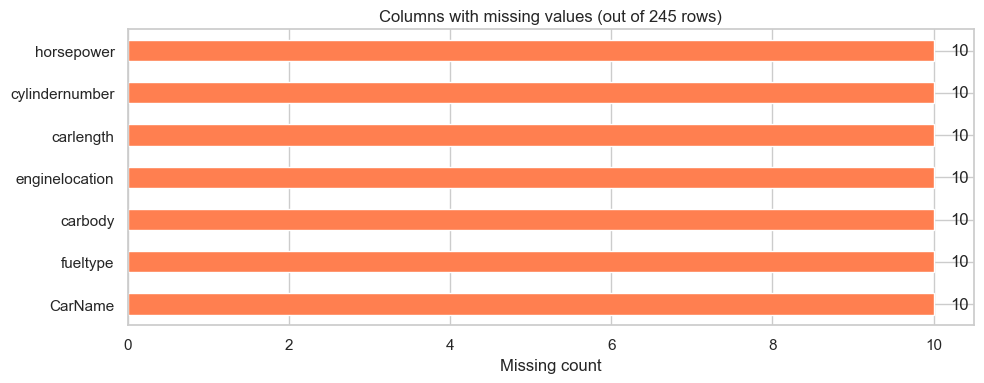

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
null_counts.plot.barh(ax=ax, color="coral")
ax.set_xlabel("Missing count")
ax.set_title("Columns with missing values (out of 245 rows)")
for i, v in enumerate(null_counts.values):
    ax.text(v + 0.2, i, str(v), va="center")
plt.tight_layout()
plt.show()

All 10 columns with nulls have exactly **10** missing values each. Let's check whether these are the same 10 rows.

In [8]:
null_rows = df[df.isnull().any(axis=1)].copy()
null_rows["missing_cols"] = null_rows.apply(
    lambda r: r.index[r.isnull()].tolist(), axis=1
)
null_rows[["car_ID", "missing_cols"]]

,car_ID,missing_cols
22,23,[cylindernumber]
25,26,[carlength]
32,33,[cylindernumber]
39,40,"[CarName, fueltype, carbody, carlength, horsep..."
42,43,[carlength]
44,45,[cylindernumber]
46,47,"[CarName, fueltype, carbody, enginelocation, h..."
57,58,"[enginelocation, cylindernumber]"
61,62,"[CarName, fueltype, carbody, carlength, cylind..."
62,63,"[CarName, fueltype, carbody, carlength, cylind..."


**Findings:**

- **10 rows** are missing `fueltype` + `carbody` simultaneously (car_IDs: 40, 47, 62, 63, 133, 161, 194, 197, 227, 242). These also tend to be missing `CarName`, `carlength`, `horsepower`, and `cylindernumber`. These rows will be **dropped** by the Lambda preprocessing because critical columns are absent.
- **17 additional rows** have isolated nulls in imputable columns (`cylindernumber`, `carlength`, `enginelocation`, `horsepower`). These rows are otherwise complete and will be **kept**.
- `drivewheel` and `Price` have **zero** nulls — good, the target is always present.

## 4. Preview: after dropping PII and critical-null rows

In [9]:
df_preview = df.drop(columns=DROP_COLS)
before = len(df_preview)
df_preview = df_preview.dropna(subset=CRITICAL_COLS)
after = len(df_preview)
print(f"Rows before: {before} -> after dropping critical nulls: {after} (dropped {before - after})")
print(f"Remaining nulls:\n{df_preview.isnull().sum()[df_preview.isnull().sum() > 0]}")

Rows before: 245 -> after dropping critical nulls: 235 (dropped 10)
Remaining nulls:
enginelocation    9
carlength         4
cylindernumber    8
dtype: int64


After removing PII columns and rows missing critical attributes, the remaining nulls are sparse and imputable.

## 5. Distribution Stats

In [10]:
df_preview.describe()

,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,compressionratio,horsepower,peakrpm,citympg,highwaympg,Price
count,235.000000,231.000000,235.000000,235.000000,235.000000,227.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000
mean,98.576596,173.641558,65.840851,53.639574,2543.331915,4.361233,126.059574,10.180979,103.157447,5115.744681,25.370213,30.957447,13041.870923
std,5.883296,12.063445,2.090769,2.430998,509.763445,1.044113,40.195844,4.056151,38.420034,470.732039,6.506667,6.842419,7757.915869
min,86.600000,141.100000,60.300000,47.800000,1488.000000,2.000000,61.000000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,94.500000,166.300000,64.050000,51.600000,2145.000000,4.000000,98.000000,8.500000,70.000000,4800.000000,19.500000,25.000000,7775.000000
50%,96.500000,173.000000,65.400000,54.100000,2405.000000,4.000000,119.000000,9.000000,95.000000,5100.000000,24.000000,30.000000,9995.000000
75%,101.200000,180.250000,66.500000,55.500000,2921.000000,4.000000,141.000000,9.400000,116.000000,5500.000000,30.000000,35.000000,16501.500000
max,120.900000,208.100000,72.300000,59.800000,4066.000000,12.000000,326.000000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [11]:
cat_cols = df_preview.select_dtypes(include="object").columns.tolist()
for col in cat_cols:
    print(f"--- {col} ---")
    print(df_preview[col].value_counts())
    print()

--- fueltype ---
fueltype
gas       211
diesel     24
Name: count, dtype: int64

--- aspiration ---
aspiration
std      192
turbo     43
Name: count, dtype: int64

--- doornumber ---
doornumber
four    130
two     105
Name: count, dtype: int64

--- carbody ---
carbody
sedan          107
hatchback       83
wagon           28
hardtop          9
convertible      8
Name: count, dtype: int64

--- drivewheel ---
drivewheel
fwd    141
rwd     84
4wd     10
Name: count, dtype: int64

--- enginelocation ---
enginelocation
front    223
rear       3
Name: count, dtype: int64

--- color ---
color
yellow     24
navy       19
olive      18
blue       18
white      17
teal       16
black      16
green      15
purple     14
aqua       14
gray       14
fuchsia    13
silver     13
lime       13
maroon     11
Name: count, dtype: int64



C:\Users\ZCsikos\AppData\Local\Temp\ipykernel_24188\1024907644.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_preview.select_dtypes(include="object").columns.tolist()


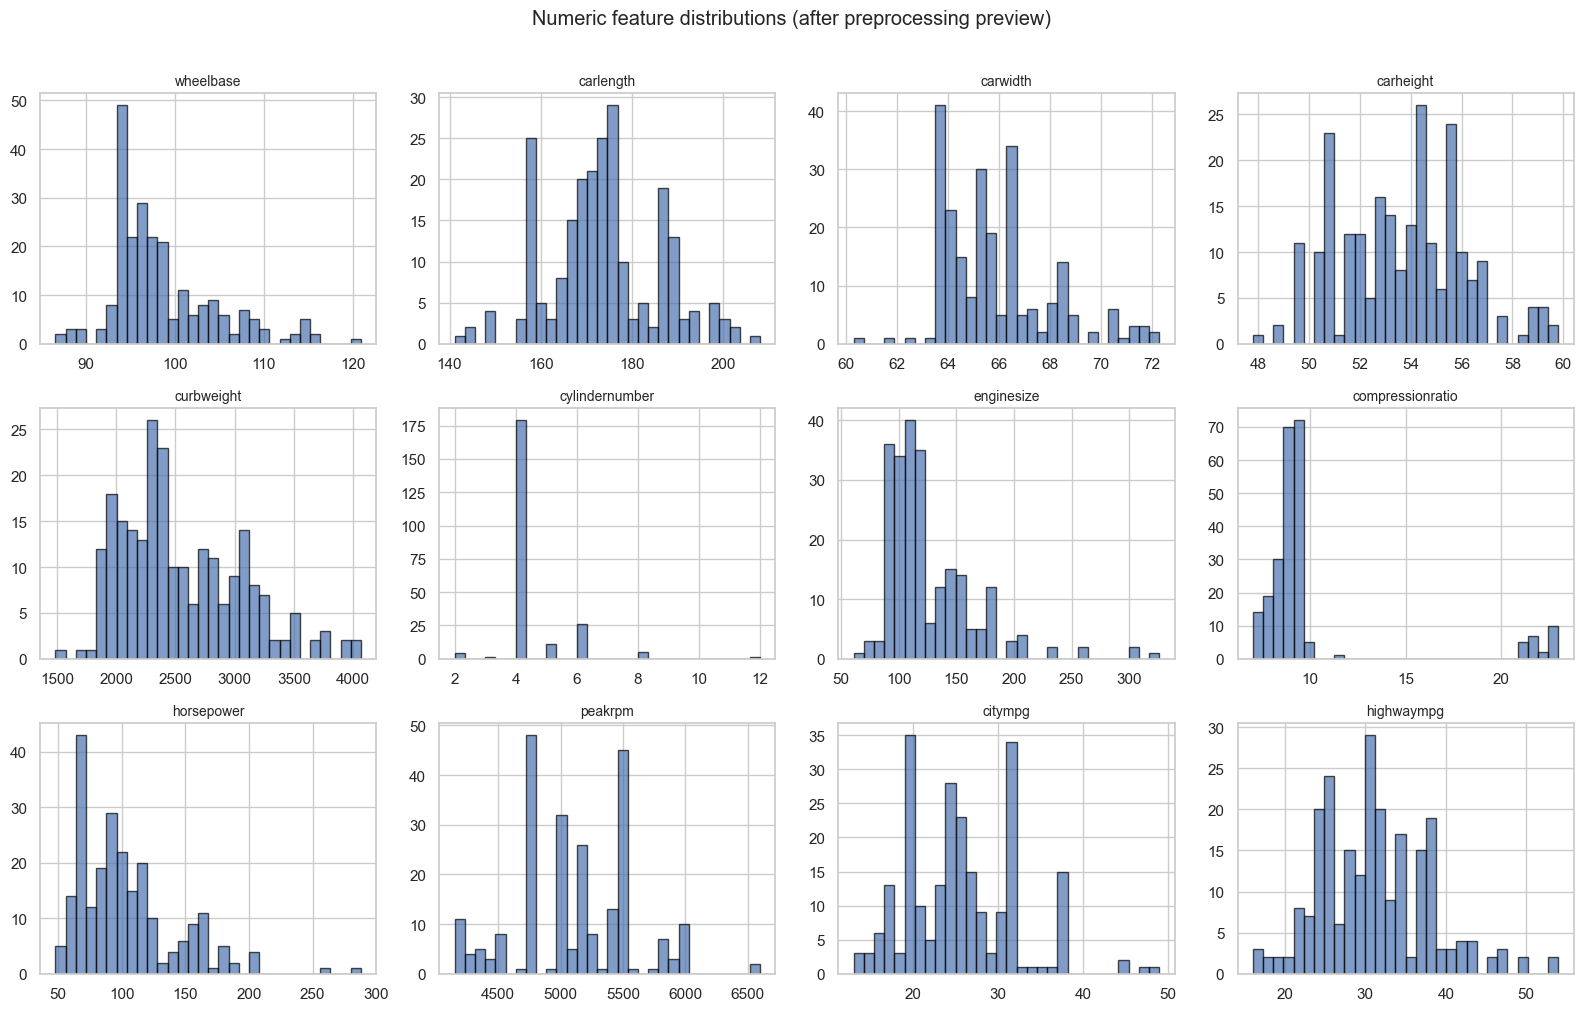

In [12]:
num_cols = df_preview.select_dtypes(include="number").columns.tolist()
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.flat, num_cols):
    df_preview[col].hist(ax=ax, bins=30, edgecolor="black", alpha=0.7)
    ax.set_title(col, fontsize=10)
for ax in axes.flat[len(num_cols):]:
    ax.set_visible(False)
fig.suptitle("Numeric feature distributions (after preprocessing preview)", y=1.01)
plt.tight_layout()
plt.show()

## 6. Correlation with Price

In [13]:
corr = df_preview.select_dtypes(include="number").corr()
price_corr = corr["Price"].drop("Price").sort_values(ascending=False)
print("Correlation with Price:")
print(price_corr.to_string())

Correlation with Price:
enginesize          0.873603
curbweight          0.839337
horsepower          0.798310
carwidth            0.764493
cylindernumber      0.711341
carlength           0.677798
wheelbase           0.579545
carheight           0.123276
compressionratio    0.087096
peakrpm            -0.105890
citympg            -0.673937
highwaympg         -0.686028


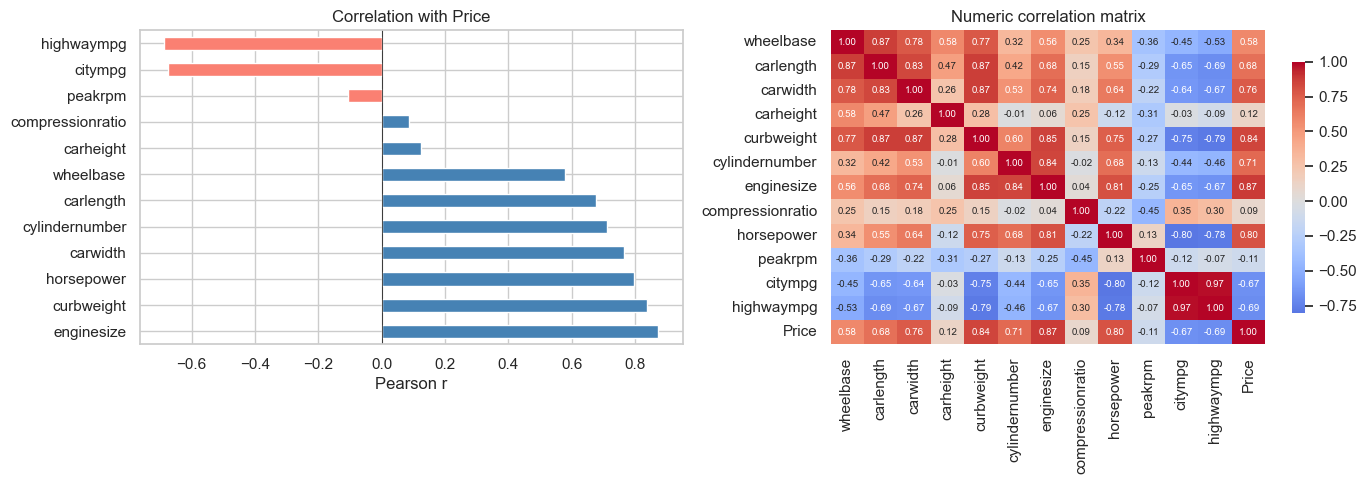

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

price_corr.plot.barh(ax=axes[0], color=price_corr.apply(lambda x: "steelblue" if x > 0 else "salmon"))
axes[0].set_title("Correlation with Price")
axes[0].set_xlabel("Pearson r")
axes[0].axvline(0, color="black", linewidth=0.5)

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            ax=axes[1], cbar_kws={"shrink": 0.8}, annot_kws={"size": 7})
axes[1].set_title("Numeric correlation matrix")

plt.tight_layout()
plt.show()

## 7. Summary

**Dataset:** 245 rows, 27 columns. Target: `Price`.

**Column groups:**
- 7 PII/non-ML columns to drop
- 4 critical columns (`carbody`, `fueltype`, `drivewheel`, `Price`) — rows missing these are dropped
- 16 remaining features (imputable)

**Missing values:** 27 rows have at least one null. 10 of these are missing critical columns and will be dropped, leaving 235 rows. The remaining 17 rows have isolated nulls in `cylindernumber` (6), `enginelocation` (9), `carlength` (3), `horsepower` (1) — all imputable.

**Strongest predictors of Price:** `enginesize` (r=0.87), `curbweight` (r=0.83), `horsepower` (r=0.80), `carwidth` (r=0.74). Negative correlations: `highwaympg` (r=-0.68), `citympg` (r=-0.67).

**Notes:**
- `color` has 15 unique values, roughly uniform — unlikely to be a strong predictor but worth including.
- `enginelocation` is 98% `front` — very low variance, may contribute little signal.
- `cylindernumber` is parsed as float (due to nulls) — should be treated as ordinal or categorical.